# Retail Intelligence Business Analytics

## Notebook 2: Data Quality Assessment

### Objective

The objective of this notebook is to evaluate the quality of the Global Superstore dataset by identifying missing values, duplicate records, inconsistent data types, invalid values, and potential anomalies before performing data cleaning and feature engineering.

In [1]:
import pandas as pd
import numpy as np

# Display all columns
pd.set_option("display.max_columns", None)

# Load Orders sheet
df = pd.read_excel(
    "../data/raw/Global Superstore Data.xlsx",
    sheet_name="Orders"
)

## Step 1: Missing Value Analysis

This step evaluates the dataset for missing values across all columns to determine whether data imputation or removal is required before analysis.

In [2]:
missing = df.isnull().sum()

missing[missing > 0]

Postal Code    41296
dtype: int64

In [3]:
missing_percent = (
    df.isnull().mean() * 100
).round(2)

missing_percent[missing_percent > 0]

Postal Code    80.51
dtype: float64

In [4]:
missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Percentage
Postal Code,41296,80.51


### Observations

- Only **Postal Code** contains missing values.
- Around 80% of Postal Code values are missing.
- Since this is a global dataset, missing postal codes are expected for several countries.

## Step 2: Duplicate Record Detection

Duplicate records can distort business metrics and lead to incorrect analytical results. This section checks whether duplicate rows exist within the dataset.

In [5]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [6]:
df[df.duplicated()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Product Name,Sub-Category,Category,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority


### Observations

- No duplicate rows were found.
- Each record appears to represent a unique transaction.

## Step 3: Data Type Validation

Verify that each feature has the appropriate data type to ensure accurate calculations and transformations in later stages.

In [7]:
df.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Postal Code              float64
City                      object
State                     object
Country                   object
Region                    object
Market                    object
Product ID                object
Product Name              object
Sub-Category              object
Category                  object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority            object
dtype: object

In [8]:
df.select_dtypes(include="object").columns

Index(['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment',
       'City', 'State', 'Country', 'Region', 'Market', 'Product ID',
       'Product Name', 'Sub-Category', 'Category', 'Order Priority'],
      dtype='object')

In [9]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Cost'],
      dtype='object')

### Observations

- Date columns are correctly stored as datetime.
- Numeric columns are ready for calculations.
- Categorical variables are stored as object type.

## 4. Unique Value Analysis

Unique value analysis helps identify identifier columns, understand the diversity of categorical features, and detect attributes that may require encoding or further investigation.

In [10]:
df.nunique().sort_values()

Segment               3
Category              3
Order Priority        4
Ship Mode             4
Market                5
Quantity             14
Sub-Category         17
Region               23
Discount             27
Country             165
Postal Code         631
Customer Name       796
State              1106
Order Date         1429
Ship Date          1463
City               3650
Product ID         3788
Product Name       3788
Shipping Cost     16452
Customer ID       17415
Sales             22995
Profit            24575
Order ID          25728
Row ID            51290
dtype: int64

In [11]:
categorical = df.select_dtypes(include="object")

categorical.nunique().sort_values()

Segment               3
Category              3
Order Priority        4
Ship Mode             4
Market                5
Sub-Category         17
Region               23
Country             165
Customer Name       796
State              1106
City               3650
Product ID         3788
Product Name       3788
Customer ID       17415
Order ID          25728
dtype: int64

### Observations

- Order ID and Customer ID behave as unique identifiers.
- Category-related fields contain expected values.
- No unusual categorical values were observed.

## 5. Numerical Summary

Reviewing descriptive statistics provides an overview of the distribution, central tendency, and variability of numerical variables before further analysis and outlier detection.

In [12]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,51290.0,25645.5,1.0,12823.25,25645.5,38467.75,51290.0,14806.29199
Order Date,51290,2016-05-11 11:52:18.436342272,2014-01-01 00:00:00,2015-06-19 00:00:00,2016-07-08 00:00:00,2017-05-22 00:00:00,2017-12-31 00:00:00,NaN
Ship Date,51290,2016-05-15 11:09:41.306297344,2014-01-03 00:00:00,2015-06-23 00:00:00,2016-07-12 00:00:00,2017-05-26 00:00:00,2018-01-07 00:00:00,NaN
Postal Code,9994.0,55190.379428,1040.0,23223.0,56430.5,90008.0,99301.0,32063.69335
Sales,51290.0,246.490581,0.444,30.758625,85.053,251.0532,22638.48,487.565361
Quantity,51290.0,3.476545,1.0,2.0,3.0,5.0,14.0,2.278766
Discount,51290.0,0.142908,0.0,0.0,0.0,0.2,0.85,0.21228
Profit,51290.0,28.610982,-6599.978,0.0,9.24,36.81,8399.976,174.340972
Shipping Cost,51290.0,26.478567,1.002,2.61,7.79,24.45,933.57,57.251373


In [13]:
df[
    ["Sales", "Profit", "Quantity", "Discount", "Shipping Cost"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,51290.0,246.490581,487.565361,0.444,30.758625,85.053,251.0532,22638.480
Profit,51290.0,28.610982,174.340972,-6599.978,0.000000,9.240,36.8100,8399.976
Quantity,51290.0,3.476545,2.278766,1.000,2.000000,3.000,5.0000,14.000
Discount,51290.0,0.142908,0.212280,0.000,0.000000,0.000,0.2000,0.850
Shipping Cost,51290.0,26.478567,57.251373,1.002,2.610000,7.790,24.4500,933.570


### Observations

- Sales and Profit have a wide range of values.
- Negative profit values indicate loss-making orders.
- Discounts vary between 0 and 0.85.

## 6. Outlier Detection

Boxplots are used to visually identify unusually high or low observations in numerical variables. Detecting outliers helps assess whether extreme values represent valid business transactions or potential data quality issues.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

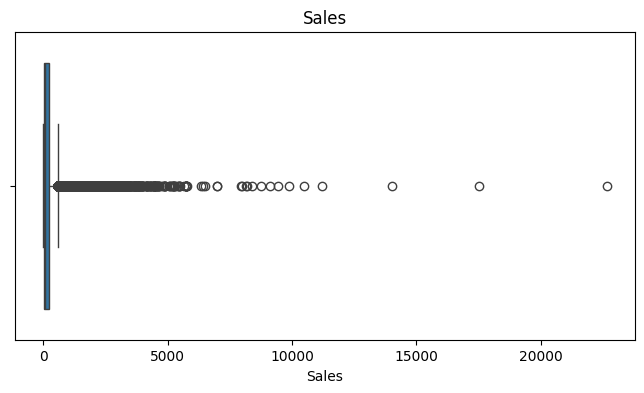

In [15]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Sales"])

plt.title("Sales")
plt.show()

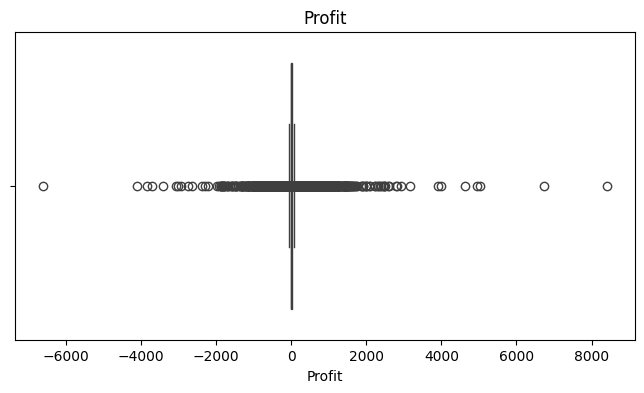

In [16]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Profit"])

plt.title("Profit")
plt.show()

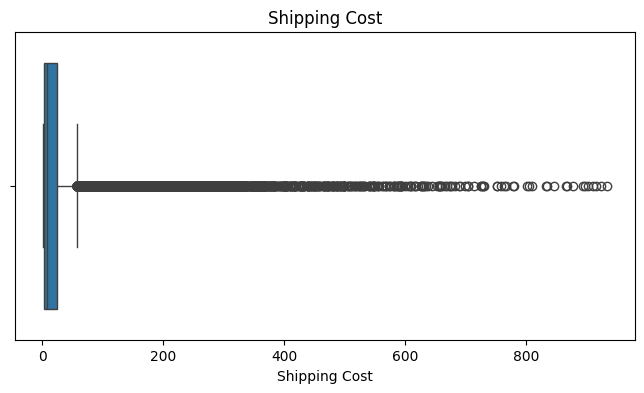

In [17]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Shipping Cost"])

plt.title("Shipping Cost")
plt.show()

### Observations

- High-value sales appear as outliers.
- Some orders generated negative profit.
- These values appear to be valid business cases rather than data errors.

# Summary

## Key Findings

The data quality assessment confirms that the Global Superstore dataset is suitable for further analysis.

### Major Findings

- Missing values were identified only in the Postal Code column.
- No duplicate records were detected.
- Data types are correctly assigned for numerical, categorical, and datetime features.
- Unique value analysis provided insights into identifier and categorical columns.
- Numerical summaries revealed expected business distributions.
- Outlier analysis identified extreme sales and profit values that represent valid business transactions rather than data errors.

The dataset is now ready for data cleaning, feature engineering, and business performance analysis in the next notebook.